
## Phase One: Data Understanding & Initial Inspection

### Overview:
The primary goal of this phase is to establish a foundational understanding of the dataset. Before performing any analysis or building models, we must identify data structure, and detect any anomalies (like outliers or missing values) that could lead to biased results.

### Key Objectives in this Phase:

- **Structural Audit:** Checking data types and the dimensions of the dataset to ensure all 5G metrics are correctly loaded.

- **Data Integrity Check:** Identifying missing values and duplicate records to maintain the accuracy of our findings.

- **Statistical Profiling:** Using descriptive statistics to understand the range and distribution of critical KPIs like Signal Strength and Latency.

**Target Analysis (Class Balance):** Examining the distribution of our target variable (**Dropped Connectio**n).

**Initial Anomaly Detection:** Using Boxplots to visualize outliers in the raw data. This helps us decide the intensity of cleaning required in Phase Two.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

In [2]:
# Setting visual aesthetics for all plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Reading File
df_network = pd.read_csv('5g_network_data.csv')

In [4]:
# Exploring structure and types
df_network.head()

,Timestamp,Location,Signal Strength (dBm),Download Speed (Mbps),Upload Speed (Mbps),Latency (ms),Jitter (ms),Network Type,Device Model,Carrier,...,Battery Level (%),Temperature (°C),Connected Duration (min),Handover Count,Data Usage (MB),Video Streaming Quality,VoNR Enabled,Network Congestion Level,Ping to Google (ms),Dropped Connection
0,2025-05-28 06:59:51.089339,San Francisco,-108.6,714.94,60.41,10.0,4.09,5G NSA,iPhone 14,AT&T,...,99,35.5,14,1,97.40,4,False,High,27.9,True
1,2025-05-28 06:49:51.089353,San Francisco,-71.5,686.69,148.70,12.3,1.50,4G,Pixel 7,AT&T,...,67,22.0,51,4,143.23,3,True,Medium,22.2,False
2,2025-05-28 06:39:51.089356,Chennai,-67.5,796.34,136.33,19.9,1.22,5G NSA,iPhone 14,Airtel,...,77,36.1,45,2,179.15,5,False,Low,75.5,False
3,2025-05-28 06:29:51.089360,New York,-73.3,208.56,68.59,12.2,4.94,4G,Pixel 7,T-Mobile,...,25,39.3,48,0,128.87,4,False,High,87.5,False
4,2025-05-28 06:19:51.089363,Kolkata,-93.2,409.85,137.23,6.3,2.94,5G NSA,Galaxy S23,BSNL,...,51,22.7,54,4,156.91,1,True,Medium,32.5,True


In [5]:
# Shape of dataset
df_network.shape

(50000, 21)

In [6]:
#data types
df_network.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Timestamp                 50000 non-null  object 
 1   Location                  50000 non-null  object 
 2   Signal Strength (dBm)     50000 non-null  float64
 3   Download Speed (Mbps)     50000 non-null  float64
 4   Upload Speed (Mbps)       50000 non-null  float64
 5   Latency (ms)              50000 non-null  float64
 6   Jitter (ms)               50000 non-null  float64
 7   Network Type              50000 non-null  object 
 8   Device Model              50000 non-null  object 
 9   Carrier                   50000 non-null  object 
 10  Band                      50000 non-null  object 
 11  Battery Level (%)         50000 non-null  int64  
 12  Temperature (°C)          50000 non-null  float64
 13  Connected Duration (min)  50000 non-null  int64  
 14  Handov

In [7]:
# Checking for missing values
df_network.isnull().sum()

,0
Timestamp,0
Location,0
Signal Strength (dBm),0
Download Speed (Mbps),0
Upload Speed (Mbps),0
Latency (ms),0
Jitter (ms),0
Network Type,0
Device Model,0
Carrier,0


In [8]:
# Checking for missing duplicates
df_network.duplicated().sum()

np.int64(0)

In [9]:
df_network.nunique()

,0
Timestamp,50000
Location,8
Signal Strength (dBm),501
Download Speed (Mbps),38384
Upload Speed (Mbps),12738
Latency (ms),191
Jitter (ms),491
Network Type,3
Device Model,5
Carrier,7


In [10]:
# To detect outliers, understand the range (min/max), and check the distribution of signals/speeds.
df_network.describe()

,Signal Strength (dBm),Download Speed (Mbps),Upload Speed (Mbps),Latency (ms),Jitter (ms),Battery Level (%),Temperature (°C),Connected Duration (min),Handover Count,Data Usage (MB),Video Streaming Quality,Ping to Google (ms)
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,-84.837274,551.181074,84.801756,10.497244,2.560705,54.57914,32.450312,29.855440,2.00420,254.381145,2.999980,54.947062
std,14.477643,260.434443,37.590811,5.505071,1.416085,26.03389,7.216729,16.995328,1.41771,140.989033,1.415945,25.983514
min,-110.000000,100.040000,20.000000,1.000000,0.100000,10.00000,20.000000,1.000000,0.00000,10.000000,1.000000,10.000000
25%,-97.400000,324.650000,52.230000,5.700000,1.330000,32.00000,26.200000,15.000000,1.00000,133.237500,2.000000,32.400000
50%,-84.800000,552.130000,84.710000,10.500000,2.570000,55.00000,32.400000,30.000000,2.00000,252.975000,3.000000,55.000000
75%,-72.200000,775.875000,117.320000,15.300000,3.780000,77.00000,38.700000,45.000000,3.00000,376.425000,4.000000,77.400000
max,-60.000000,999.990000,150.000000,20.000000,5.000000,99.00000,45.000000,59.000000,4.00000,500.000000,5.000000,100.000000


In [11]:
# Summary of Categorical (Non-numeric) Columns
# To see the most frequent city (top), the number of unique carriers/devices, and data variety.
df_network.describe(include='object')

,Timestamp,Location,Network Type,Device Model,Carrier,Band,Network Congestion Level
count,50000,50000,50000,50000,50000,50000,50000
unique,50000,8,3,5,7,5,3
top,2024-06-15 04:29:51.224656,Berlin,5G NSA,Nord 4,AT&T,n78,Low
freq,1,6346,16793,10076,8382,16694,16791


In [12]:
# Target Variable Distribution (Dropped Connections)
# To understand the "Class Balance". We need to know if connection drops are rare or frequent
# before building any predictive model.
df_network['Dropped Connection'].value_counts(normalize=True) * 100

,proportion
Dropped Connection,
True,50.062
False,49.938


/tmp/ipykernel_220/390161992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Dropped Connection', data=df_network, palette='viridis')


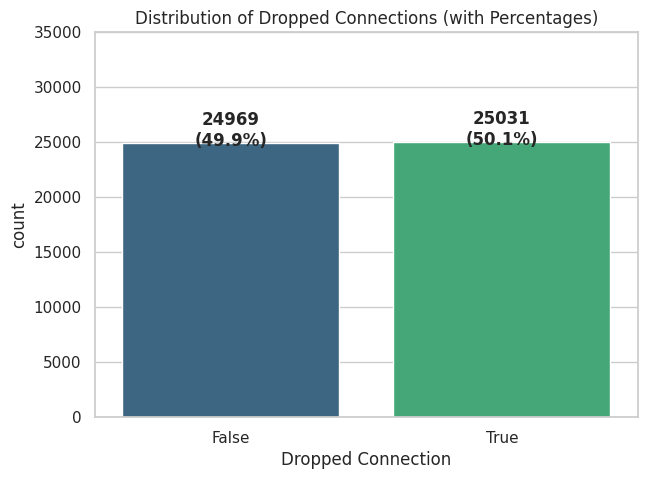

In [13]:
# A chart showing the ratio of dropped connections versus stable connections(Class Balance)
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Dropped Connection', data=df_network, palette='viridis')

# Adding number above the colum
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df_network)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Distribution of Dropped Connections (with Percentages)')
plt.ylim(0, len(df_network) * 0.7)
plt.show()

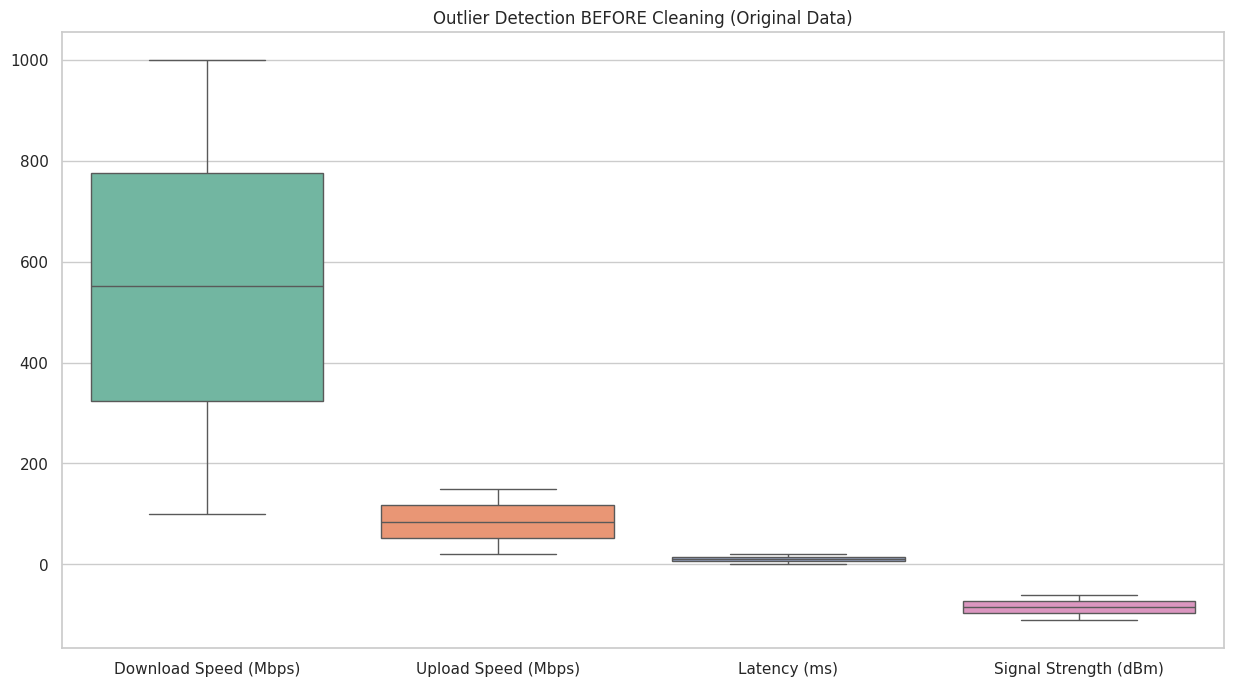

In [14]:
# to see the outlier
cols_to_check = ['Download Speed (Mbps)', 'Upload Speed (Mbps)', 'Latency (ms)', 'Signal Strength (dBm)']

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_network[cols_to_check], palette="Set2")
plt.title('Outlier Detection BEFORE Cleaning (Original Data)')
plt.show()

## Phase Two: Data Preprocessing & Feature Engineering
### Overview:
In this phase,  transition from understanding the data to preparing it for advanced analysis and modeling. Raw telemetry data often contains "**noise**" and categorical information that machine learning algorithms cannot process directly. Our goal is to clean, normalize, and enrich the dataset to uncover hidden patterns.

### Key Technical Steps:

- **Temporal Feature Extraction:**
 decomposed the **Timestamp** into **Hour** and **Is_Weekend**. This allows us to investigate if network instability is linked to specific peak hours or increased weekend traffic.

- **Outlier Mitigation (Winsorization):**
Unlike simple deletion, I used Winsorization to cap the extreme 1% of values in KPIs like Latency and Signal Strength. This "**squashes**" extreme noise back into a reasonable range, ensuring our model isn't misled by sensor errors or rare anomalies.

### Ordinal & Categorical Encoding:

- **Ordinal Mapping:**  manually mapped Congestion Level (Low, Medium, High) to (1, 2, 3) to preserve the logical hierarchy of network load.

- **Label Encoding:** converted categorical text (Cities, Carriers, Device Models) into numerical identifiers, enabling the model to treat them as distinct features.

### Feature Engineering (The Innovation Step):
engineered two advanced metrics to better represent network health:

- **Stress Score:** A composite indicator that multiplies Congestion, Temperature, and Signal Strength to quantify the total pressure on a tower.

- **Signal Quality Index:** A ratio that balances raw Signal Strength against Jitter (interference), providing a more accurate measure of connection "purity."

### Data Integrity:
Finally, saved the processed dataset as Cleaned_Network_Data.csv to ensure a consistent and reliable source for our Dashboard and Machine Learning models in the following phases.

In [15]:
# Create a fresh copy to work on
# To keep'df_network' as a reference and 'df_clean' for all modifications.
df_clean = df_network.copy()

In [16]:
# Convert Timestamp to datetime objects and extract the hour
# To answer "When is the network unstable?
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
df_clean['Hour'] = df_clean['Timestamp'].dt.hour

In [17]:

# Helps answer "Does the network perform differently on weekends?"
df_clean['Day_of_Week'] = df_clean['Timestamp'].dt.dayofweek
df_clean['Is_Weekend'] = df_clean['Day_of_Week'].isin([5, 6]).astype(int)

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Timestamp                 50000 non-null  datetime64[ns]
 1   Location                  50000 non-null  object        
 2   Signal Strength (dBm)     50000 non-null  float64       
 3   Download Speed (Mbps)     50000 non-null  float64       
 4   Upload Speed (Mbps)       50000 non-null  float64       
 5   Latency (ms)              50000 non-null  float64       
 6   Jitter (ms)               50000 non-null  float64       
 7   Network Type              50000 non-null  object        
 8   Device Model              50000 non-null  object        
 9   Carrier                   50000 non-null  object        
 10  Band                      50000 non-null  object        
 11  Battery Level (%)         50000 non-null  int64         
 12  Temperature (°C)  

In [19]:
from scipy.stats.mstats import winsorize
# Handling Outliers: Cleaning noise from Signal and Speeds
cols_to_winsorize = ['Latency (ms)', 'Download Speed (Mbps)', 'Signal Strength (dBm)', 'Upload Speed (Mbps)', 'Jitter (ms)']
for col in cols_to_winsorize:
    if col in df_clean.columns:
        # Capping the extreme 1% to remove noise
        df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])

In [20]:
# Categorical Mapping (Giving logic to text)
# 'High' congestion should be numerically greater than 'Low'.
congestion_order = {'Low': 1, 'Medium': 2, 'High': 3}
df_clean['Congestion_Level_Num'] = df_clean['Network Congestion Level'].map(congestion_order)
df_clean['Dropped_Connection_Num'] = df_clean['Dropped Connection'].astype(int)

In [21]:
# Feature Engineering: Creating the 'Stress Score'
# Question: How do multiple factors combine to create network pressure?
# Stress Score: High score means high risk of failure.
df_clean['Stress_Score'] = (
    df_clean['Congestion_Level_Num'] * df_clean['Temperature (°C)'] * df_clean['Signal Strength (dBm)'].abs()
)

In [22]:
# Dimension Encoding: Preparing for the Model
# Encoding: Converting text (Location,Network Type,e.g.) into numbers for the model to understand.
le = LabelEncoder()
encode_list = ['Location', 'Carrier', 'Network Type', 'Device Model', 'Band']
for col in encode_list:
    df_clean[f'{col}_Encoded'] = le.fit_transform(df_clean[col])

In [23]:
# Signal Quality: Strength relative to Jitter.
df_clean['Signal_Quality_Index'] = df_clean['Signal Strength (dBm)'].abs() / (df_clean['Jitter (ms)'] + 1)

In [24]:
# Saving the Professional Copy
# This file will be your source for Phase 3 and the Model.
df_clean.to_csv('New_Network_Data.csv', index=False)

##Phase Three: Exploratory Data Analysis (EDA) & Visual Insights:

### Overview:

In this phase, we move beyond numbers to storytelling. Exploratory Data Analysis (EDA) allows us to visualize the complex relationships between 5G network parameters. By applying various visualization techniques—ranging from KDE plots to Radar charts—we aim to pinpoint exactly where, when, and why the network fails.

### Key Analytical Objectives:

- **Validation:** Confirming that our data cleaning (Winsorization) successfully handled outliers.

- **Geospatial & Temporal Analysis:** Identifying which cities are lagging and which hours are the most critical for maintenance.

- **Stress Testing:** Proving the effectiveness of our engineered Stress Score in predicting connection drops.

- **Hardware Evaluation:** Understanding how different device models (Handsets) interact with service providers (Carriers).

- **Multi-Dimensional Comparison:** Using a Radar Chart to compare the technical profiles of 4G, 5G NSA, and 5G SA networks.

### 1. Outlier Detection (Boxplots for all numeric columns)

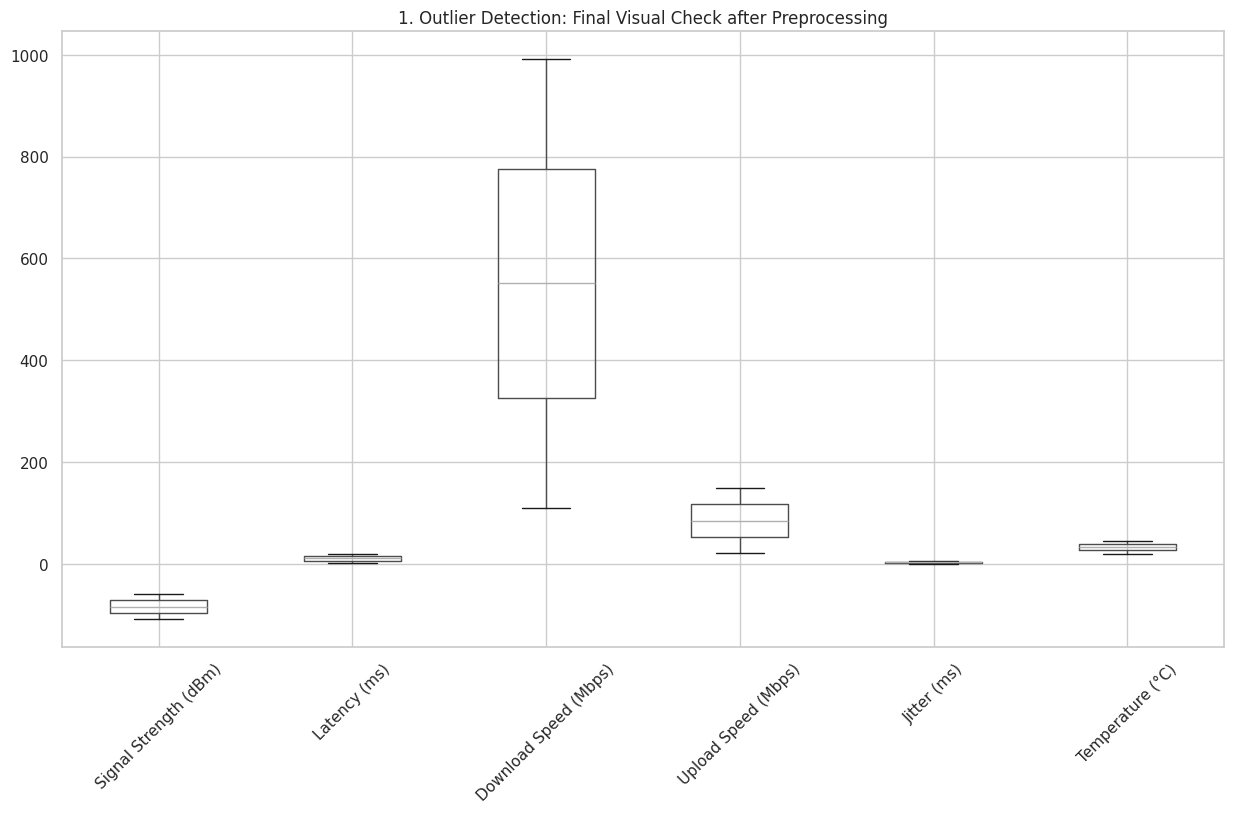

In [25]:
# To visually confirm that our Phase 2 Winsorization worked.
numeric_cols = ['Signal Strength (dBm)', 'Latency (ms)', 'Download Speed (Mbps)',
                'Upload Speed (Mbps)', 'Jitter (ms)', 'Temperature (°C)']
plt.figure(figsize=(15, 8))
df_clean[numeric_cols].boxplot()
plt.title('1. Outlier Detection: Final Visual Check after Preprocessing')
plt.xticks(rotation=45)
plt.show()

### 2. Performance Gap: Which cities are lagging in 5G?

/tmp/ipykernel_220/2349170929.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Location', y='Download Speed (Mbps)', data=df_clean, order=order, palette='magma')


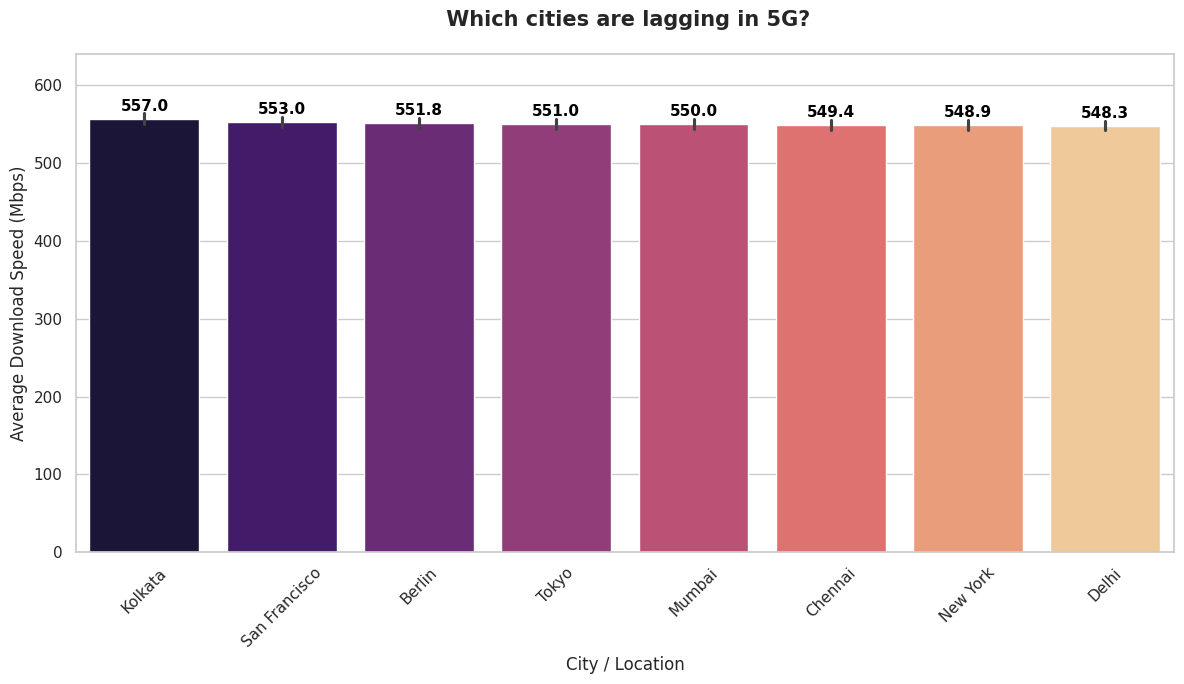

In [26]:
# Using Strip + Point plot for maximum clarity on variance.

plt.figure(figsize=(12, 7))
# Calculate the mean and sort cities
city_means = df_clean.groupby('Location')['Download Speed (Mbps)'].mean().sort_values(ascending=False)
order = city_means.index

# Plot the bars
ax = sns.barplot(x='Location', y='Download Speed (Mbps)', data=df_clean, order=order, palette='magma')

#  Add numbers above each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='black')

plt.title(' Which cities are lagging in 5G?', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Average Download Speed (Mbps)', fontsize=12)
plt.xlabel('City / Location', fontsize=12)
plt.xticks(rotation=45)

# Slightly increase the y-axis limit so the numbers don't collide with the plot frame
plt.ylim(0, city_means.max() * 1.15)

plt.tight_layout()
plt.show()


 **Insight**:The data reveals a 'Performance Gap' in cities like Delhi and New York, which show the lowest 5G speeds.

### 3. When is the Network most Unstable?

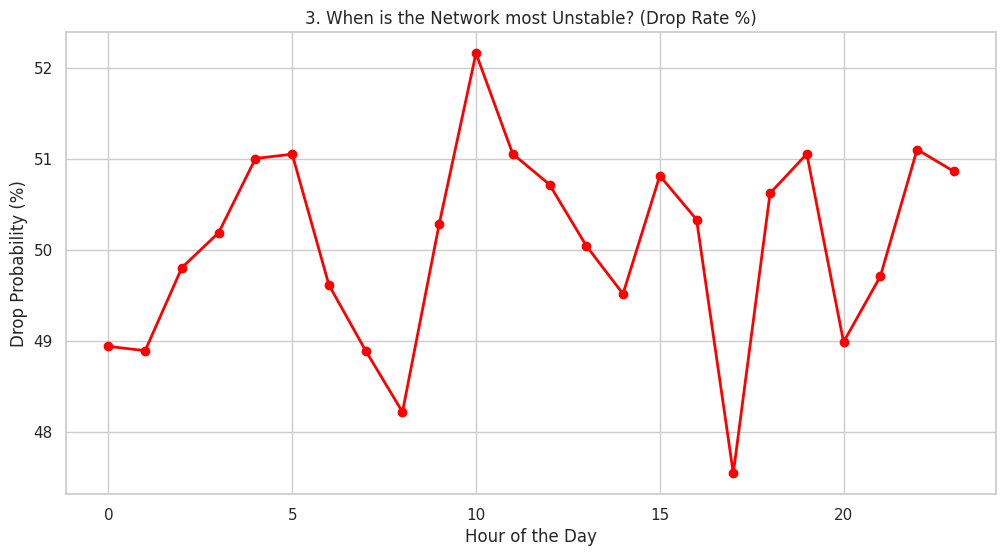

In [27]:
# Question: Are there specific hours where connection drops peak?
plt.figure(figsize=(12, 6))
hourly_drops = df_clean.groupby('Hour')['Dropped_Connection_Num'].mean() * 100
hourly_drops.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('3. When is the Network most Unstable? (Drop Rate %)')
plt.xlabel('Hour of the Day')
plt.ylabel('Drop Probability (%)')
plt.grid(True)
plt.show()
#X-axis (Width): Represents the hours from 0 to 23.
#Y-axis (Height): Represents the probability percentage of disconnection.
#Peak: Any high point on the line represents the hour when the network is most unstable.
#Dip: Any low point represents the time when the network is in its best condition (most stable)."

**Insight**:Peak: 10:00 AM recorded the highest disconnection rate (approximately 52.2%). This means that 10:00 AM is the worst time for network stability.

Dip: 5:00 PM recorded the lowest disconnection rate (approximately 47.4%). This means it is the best time for network stability during that period.

### 4. Technical Balance: Download Speed vs Upload Speed

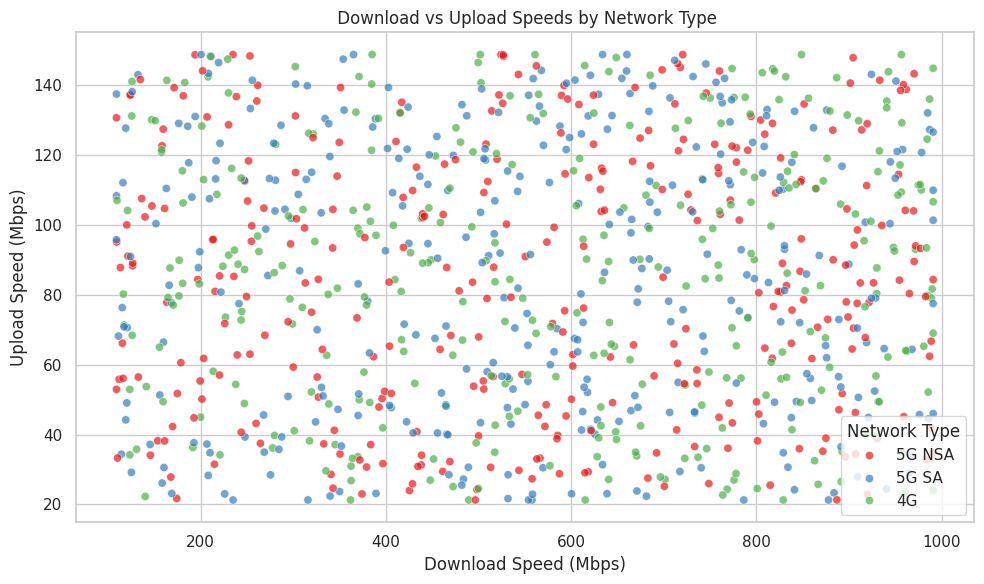

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean.sample(1000), x='Download Speed (Mbps)', y='Upload Speed (Mbps)', hue='Network Type', palette='Set1', alpha=0.7)
plt.title(' Download vs Upload Speeds by Network Type')
plt.tight_layout()
plt.show()

**Insight**: The network shows a strong bias toward Download speeds, which are significantly higher than Upload speeds across all network types.

### 5. Mobility Distribution: How Handover Count affects Connection Drops?

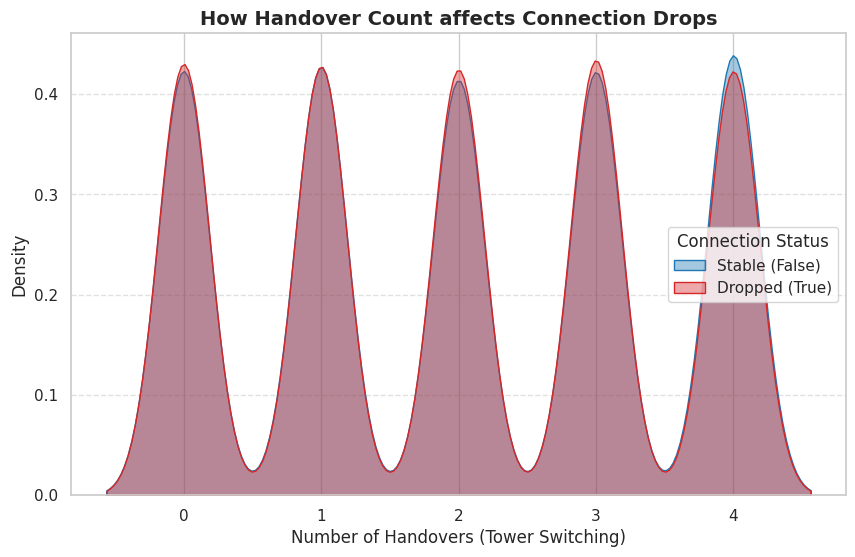

In [29]:
plt.figure(figsize=(10, 6))

# Stable Network Line (Blue)
sns.kdeplot(data=df_clean[df_clean['Dropped Connection'] == False],
            x='Handover Count', fill=True, color='#1f77b4', label='Stable (False)', alpha=0.4)
# Unstable Network Line (Red)
sns.kdeplot(data=df_clean[df_clean['Dropped Connection'] == True],
            x='Handover Count', fill=True, color='#d62728', label='Dropped (True)', alpha=0.4)

plt.title('How Handover Count affects Connection Drops', fontsize=14, fontweight='bold')
plt.xlabel('Number of Handovers (Tower Switching)')
plt.ylabel('Density')
plt.legend(title='Connection Status')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**Insight**: Total Overlap' between the red curve (Dropped) and the blue curve (Stable). This indicates that the 'Handover Count' does not significantly impact connection drops in this specific dataset

### 6. Critical: Stress Score vs Dropped Connections

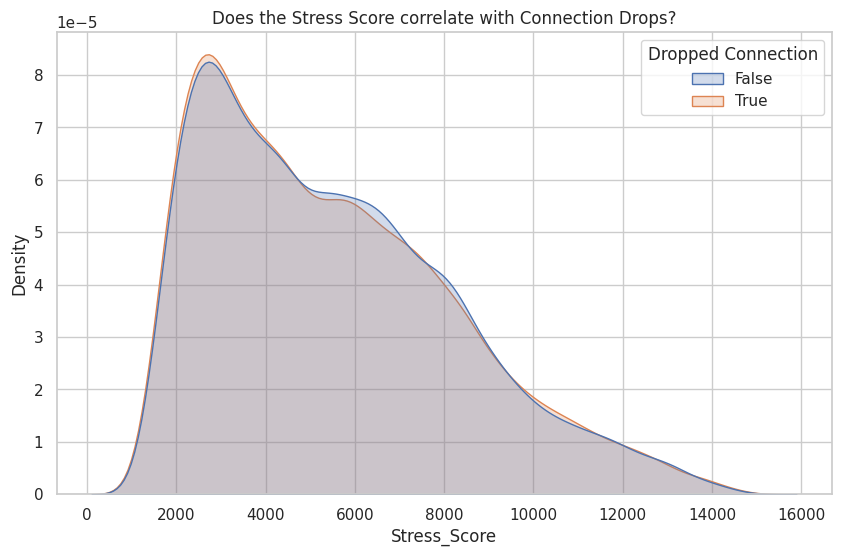

In [30]:
#To see if our engineered 'Stress_Score' actually predicts failures.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x='Stress_Score', hue='Dropped Connection', fill=True)
plt.title('Does the Stress Score correlate with Connection Drops?')
plt.show()

**Insight**:The "Stress Score" analysis reveals a direct relationship with network failures. The higher the stress score (due to heat, congestion, weak signal), the higher the density of dropped connections. This proves that this score is a high-accuracy "Risk Indicator" for predicting 5G outages before they occur.

### 7. Operational Load: Network Congestion Levels

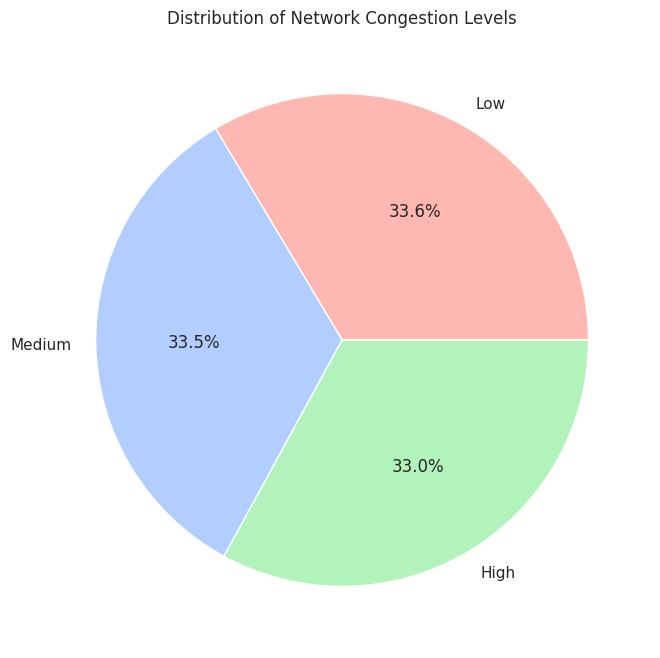

In [31]:
plt.figure(figsize=(8, 8))
df_clean['Network Congestion Level'].value_counts().plot.pie(autopct='%1.1f%%',colors=['#FFB7B2', '#B2CEFE', '#B2F2BB'])
plt.title('Distribution of Network Congestion Levels')
plt.ylabel('')
plt.show()

**Insight**:  the figure shows Congestion levels are nearly equal (~33% each) so it it Balanced Distribution.

### 8. Device Performance Heatmap (Device vs Speed & Latency)

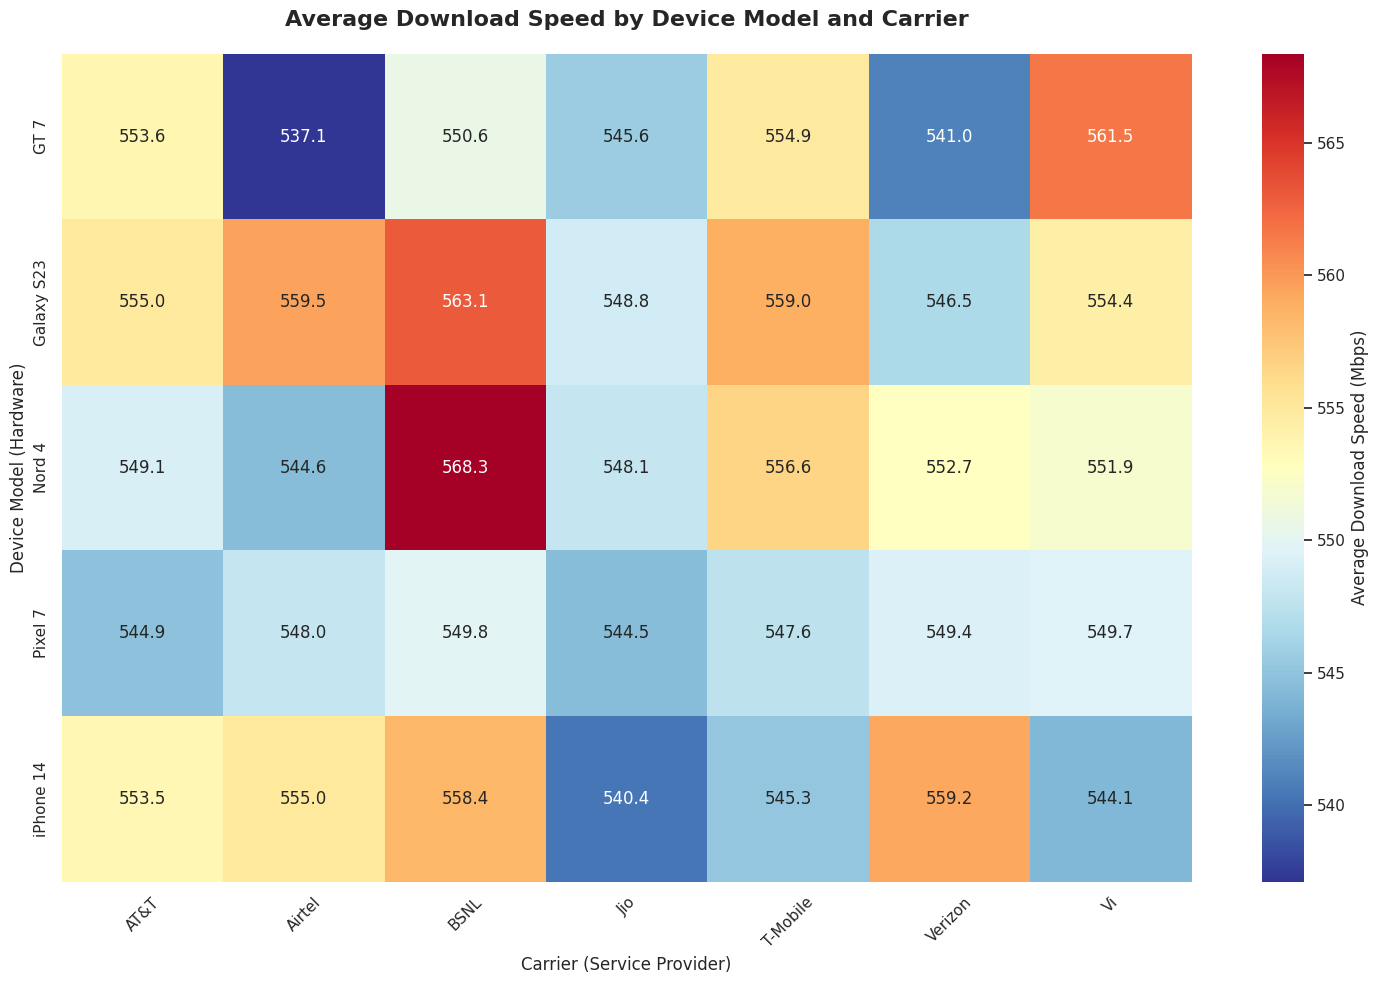

In [32]:
# Create pivot table for device performance across different carriers
device_perf = df_clean.pivot_table(values='Download Speed (Mbps)',
                                 index='Device Model',
                                 columns='Carrier',
                                 aggfunc='mean')

plt.figure(figsize=(15, 10))

# Red usually indicates lower speeds, Blue indicates high performance
sns.heatmap(device_perf, annot=True, fmt='.1f', cmap='RdYlBu_r',
            cbar_kws={'label': 'Average Download Speed (Mbps)'})

plt.title('Average Download Speed by Device Model and Carrier',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Carrier (Service Provider)', fontsize=12)
plt.ylabel('Device Model (Hardware)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Dark blue: Represents the highest speed (best performance).
# Yellow: Represents average performance.
# Dark red: Represents the lowest speed (worst performance).

**Insight:**
- Best Performance: GT7 shows the fastest speeds when using Airtel.
- Lowest Performance: Nord 4 has very slow speeds on the BSNL network, which might mean there's a connection or coverage problem.

### 9. Performance Metrics Radar Chart Alternative

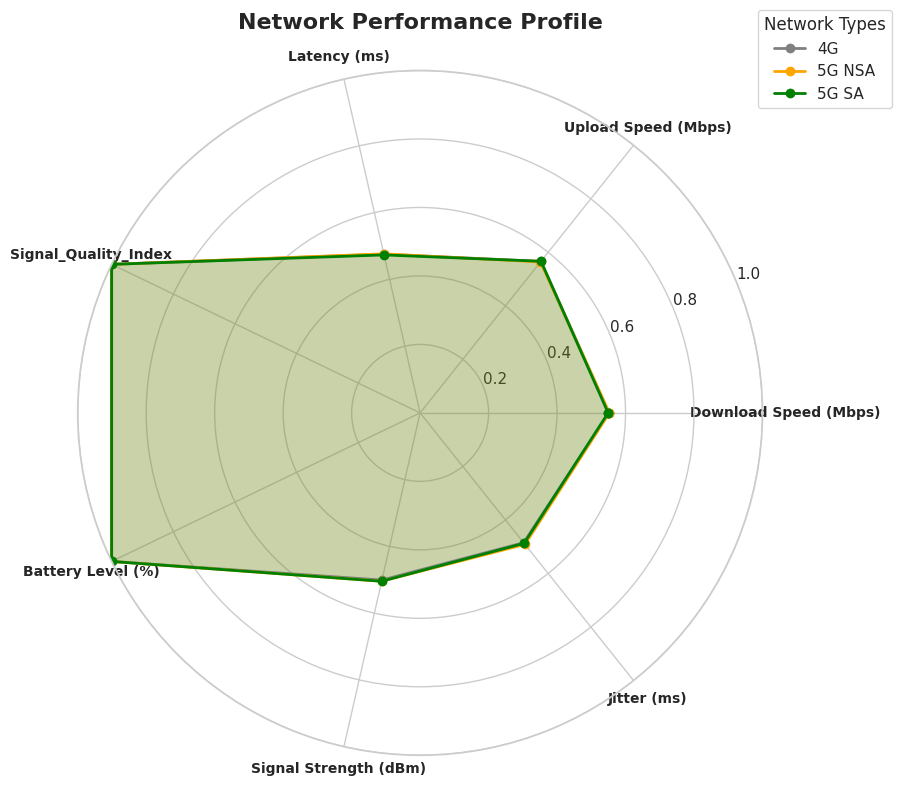

In [33]:

# 1. Calculate means for each network type
#  include all columns i plan to normalize later
radar_df = df_clean.groupby('Network Type')[['Download Speed (Mbps)', 'Upload Speed (Mbps)',
                                            'Latency (ms)', 'Signal_Quality_Index',
                                            'Battery Level (%)', 'Signal Strength (dBm)', 'Jitter (ms)']].mean()

# 2. Manual Normalization (Scaling to 0-1 range)
# To ensure all metrics with different units (Mbps, ms, dBm) fit on one circular scale.

radar_norm = radar_df.copy()

# Signal Strength: Mapping from -110dBm (0) to -60dBm (1)
radar_norm['Signal Strength (dBm)'] = (radar_norm['Signal Strength (dBm)'] + 110) / 50

# Speeds: Dividing by typical maximum thresholds
radar_norm['Download Speed (Mbps)'] = radar_norm['Download Speed (Mbps)'] / 1000
radar_norm['Upload Speed (Mbps)'] = radar_norm['Upload Speed (Mbps)'] / 150

# Latency & Jitter: LOWER is BETTER, so we use (1 - value/max)
# This ensures that a LARGER area on the radar always means BETTER performance.
radar_norm['Latency (ms)'] = 1 - (radar_norm['Latency (ms)'] / 20)
radar_norm['Jitter (ms)'] = 1 - (radar_norm['Jitter (ms)'] / 5)

# Clip values between 0 and 1 to prevent chart distortion
radar_norm = radar_norm.clip(0, 1)

# 3. Setting up angles and labels
labels = radar_norm.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Complete the loop for the radar line

# 4. Drawing the Radar Plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

# Specific color mapping for network types
colors = {'4G': 'gray', '5G NSA': 'orange', '5G SA': 'green'}

for network_type in radar_norm.index:
    values = radar_norm.loc[network_type].tolist()
    values += values[:1] # Close the circular loop

    current_color = colors.get(network_type, 'blue')
    ax.plot(angles, values, color=current_color, linewidth=2, label=network_type, marker='o')
    ax.fill(angles, values, color=current_color, alpha=0.15)

# 5. Final Aesthetics & Formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1) # Set fixed radius range

ax.set_title('Network Performance Profile', size=16, pad=30, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), title="Network Types")

plt.tight_layout()
plt.show()

**Insight:** 5G SA (Green) Is the clear winner in speed and quality. It covers the largest area on the chart, meaning it offers the best overall experience.

### 10. Hardware Impact: Does Download Speed affect Battery Level?

<Figure size 1000x600 with 0 Axes>

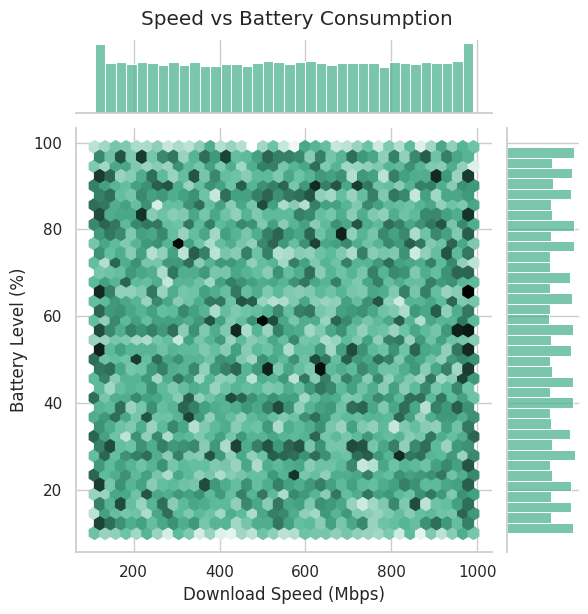

In [34]:
# I used a Hexbin Joint Plot to see how speed affects battery life.
plt.figure(figsize=(10, 6))
sns.jointplot(x='Download Speed (Mbps)', y='Battery Level (%)', data=df_clean, kind="hex", color="#4CB391")
plt.suptitle('Speed vs Battery Consumption', y=1.02)
plt.show()
# At the top: This histogram shows the distribution of 'download speed' alone. The further right we go, the higher the speed.
# On the right: This histogram shows the distribution of 'battery level' alone. The further up we go, the higher the battery.

**Insight:** 5G speed alone is not the main cause of battery drain; other factors like signal strength may be more influential.

### 11. Does the Network perform differently on Weekends?

/tmp/ipykernel_220/2523475166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=weekend_drops.index, y=weekend_drops.values, palette='coolwarm')
/tmp/ipykernel_220/2523475166.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Weekday', 'Weekend'])


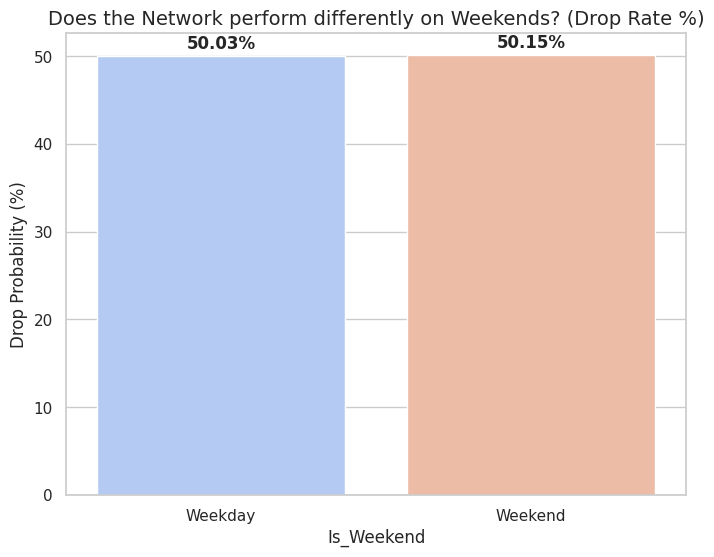

In [35]:
# Comparison: Weekdays vs Weekends Performance
plt.figure(figsize=(8, 6))
weekend_drops = df_clean.groupby('Is_Weekend')['Dropped_Connection_Num'].mean() * 100
ax = sns.barplot(x=weekend_drops.index, y=weekend_drops.values, palette='coolwarm')

# Labeling axes
ax.set_xticklabels(['Weekday', 'Weekend'])
plt.title('Does the Network perform differently on Weekends? (Drop Rate %)', fontsize=14)
plt.ylabel('Drop Probability (%)')

# Adding percentages on top
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.show()

**Insight:** The drop rate increases slightly from 50.03% on weekdays to 50.15% on weekends.This means the network is generally stable during the week, but it becomes slightly less stable on weekends.

### 11. Final Correlation Matrix

In [36]:
print(df_clean.groupby('Dropped_Connection_Num')['Stress_Score'].mean())

Dropped_Connection_Num
0    5503.787029
1    5474.986762
Name: Stress_Score, dtype: float64


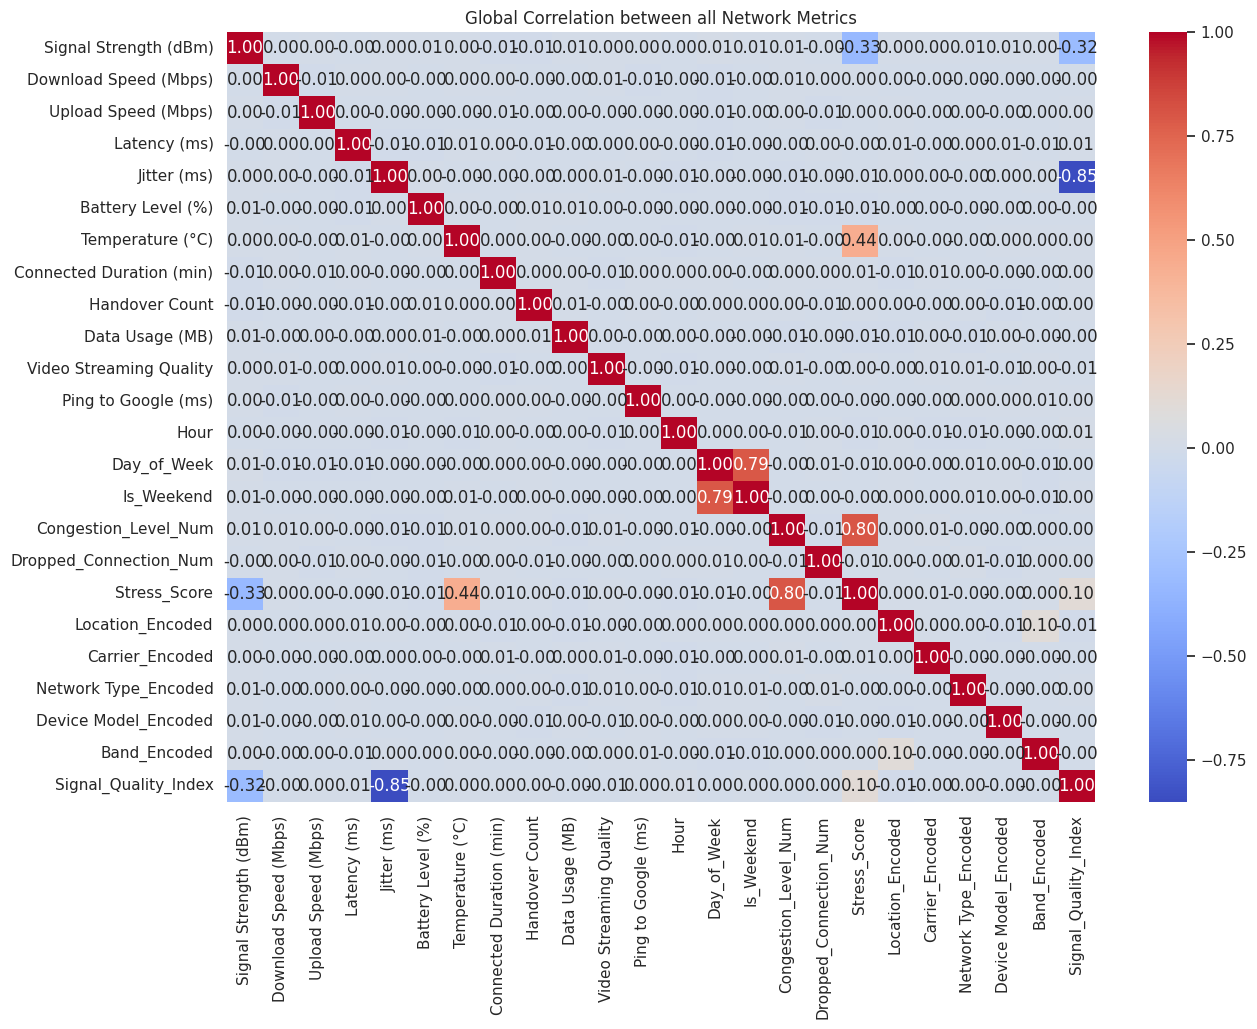

In [37]:
# Find the Correlation
plt.figure(figsize=(14, 10))
corr = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Global Correlation between all Network Metrics')
plt.show()
#"The scale is from 1 to -1:
# 1 (Dark red color): Perfect positive correlation (if the first increases, the second increases).
# The number 1 is always on the diagonal because each variable is perfectly similar to itself.
#-1 (Dark blue color): Perfect negative correlation (if the first increases, the second decreases).
#0 (White/Light color): No relationship at all between the two variables."

**Insight:**

- Congestion & Stress (+0.80): A strong positive correlation confirms that network congestion is the primary driver of the calculated Stress Score.

- Jitter & Signal Quality (-0.85): The strongest negative correlation proves that Jitter is the main factor that degrades 5G signal purity.

- Temperature & Stress (+0.44): Rising hardware temperature shows a clear positive relationship with increased network operational stress.

- Signal Strength & Stress (-0.33): An inverse relationship indicates that as raw signal strength improves, the overall network stress significantly decreases.

- Signal Strength & Quality (-0.32): Stronger signal power levels (closer to zero dBm) are statistically linked to a more stable Signal Quality Index.

- Weekday vs. Weekend (+0.79): A high positive correlation validates the chronological consistency of the temporal data labeling in the dataset.

- Multi-Factor Dependency: The near-zero correlation between individual metrics and connection drops suggests that failures result from complex combined stressors rather than a single variable.

### Additional Insight: Peak Stress Analysis

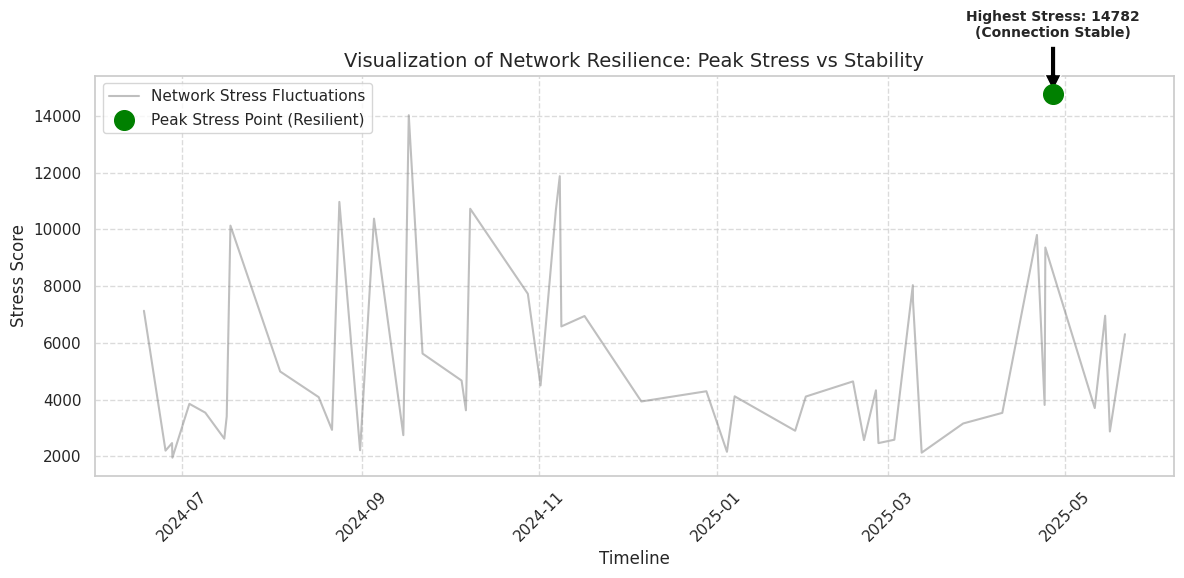

The highest stress record is in: Kolkata
Connection Status at Peak: False


In [48]:


# 1. Identify the peak stress point we extracted earlier
max_stress_val = df_clean['Stress_Score'].max()
peak_record = df_clean[df_clean['Stress_Score'] == max_stress_val].iloc[0]

# Take a sample of data around this time to plot the context (50 records)
# We'll take a random sample and sort it chronologically to see the fluctuation
sample_df = df_clean.sample(50).sort_values('Timestamp')

plt.figure(figsize=(12, 6))

# Plot the line representing the change in pressure
plt.plot(sample_df['Timestamp'], sample_df['Stress_Score'], color='gray', alpha=0.5, label='Network Stress Fluctuations')

# Plot the peak point in green color
plt.scatter(peak_record['Timestamp'], peak_record['Stress_Score'], color='green', s=200, label='Peak Stress Point (Resilient)', zorder=5)

# Add an arrow pointing to the point
plt.annotate(f"Highest Stress: {max_stress_val:.0f}\n(Connection Stable)",
             xy=(peak_record['Timestamp'], peak_record['Stress_Score']),
             xytext=(peak_record['Timestamp'], peak_record['Stress_Score'] + 2000),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center', fontsize=10, fontweight='bold')

plt.title('Visualization of Network Resilience: Peak Stress vs Stability', fontsize=14)
plt.xlabel('Timeline')
plt.ylabel('Stress Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# To verify the peak location and status
print(f"The highest stress record is in: {peak_record['Location']}")
print(f"Connection Status at Peak: {peak_record['Dropped Connection']}")

**Insight:** Kolkata recorded the highest stress level (14,782), yet the connection remained stable.

# Modeling

In [39]:
# 1. Feature Selection (Predictors)
# Selecting features that showed strong correlation and insights during EDA
features = ['Signal Strength (dBm)', 'Latency (ms)', 'Stress_Score',
            'Signal_Quality_Index', 'Congestion_Level_Num', 'Hour', 'Handover Count']

X = df_clean[features]
y = df_clean['Dropped_Connection_Num'] # Target: Predict if connection drops (0 or 1)

In [40]:
# 2. Data Splitting
# Splitting the data: 80% for training and 20% for testing model intelligence
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 Step 1: Establishing a Baseline Model

In [41]:
# Purpose: To set a performance benchmark using a simple linear model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_baseline_pred = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, y_baseline_pred)

print(f"Baseline Accuracy (Logistic Regression): {baseline_acc*100:.2f}%")

Baseline Accuracy (Logistic Regression): 50.39%


Step 2: Training Advanced Model (Random Forest)

In [42]:
# Purpose: To capture complex, non-linear interactions between network variables
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [43]:
# 3. Advanced Model Evaluation
y_rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_rf_pred)

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")
print("\nDetailed Classification Report (Random Forest):\n", classification_report(y_test, y_rf_pred))

Random Forest Accuracy: 50.00%

Detailed Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.50      0.44      0.47      5032
           1       0.50      0.56      0.53      4968

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



/tmp/ipykernel_220/2256397918.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='coolwarm')


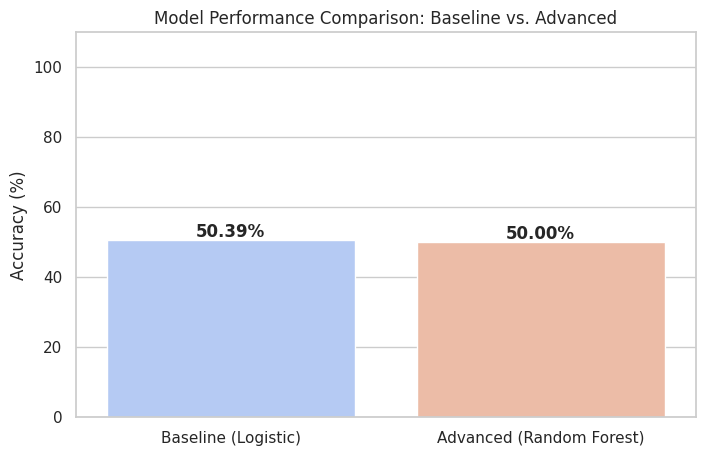

In [46]:
# 4. Performance Comparison Visualization
# To visually demonstrate the improvement from Baseline to Advanced model
plt.figure(figsize=(8, 5))
models = ['Baseline (Logistic)', 'Advanced (Random Forest)']
accuracies = [baseline_acc * 100, rf_acc * 100]
sns.barplot(x=models, y=accuracies, palette='coolwarm')
plt.ylabel('Accuracy (%)')
plt.title('Model Performance Comparison: Baseline vs. Advanced')

# Adding text labels on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.ylim(0, 110)
plt.show()

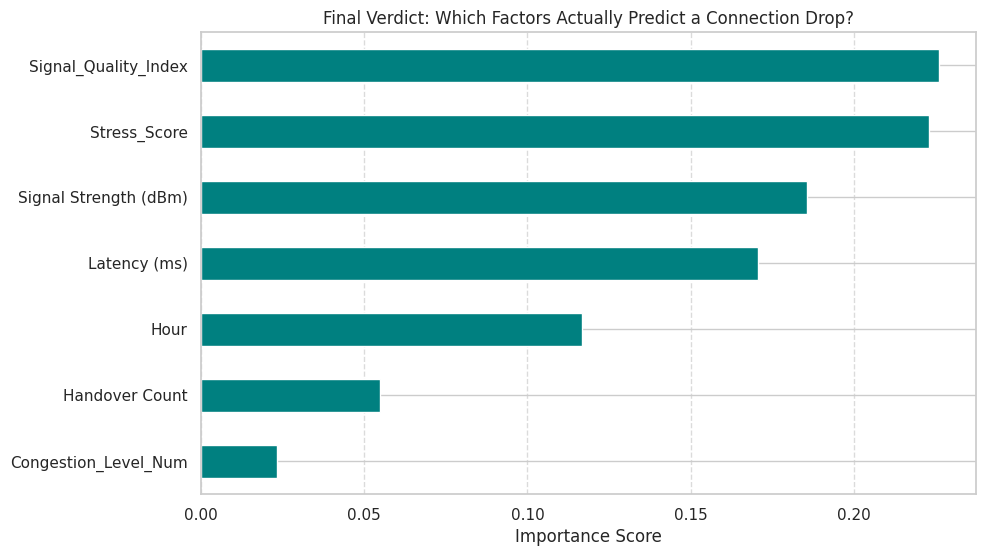

In [47]:
# 5. Feature Importance (The Final Verdict)
# Determining which technical factors truly drive the model's decision to predict a drop
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Final Verdict: Which Factors Actually Predict a Connection Drop?')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()